### Objective

This notebook integrates DepMap transcriptomic expression data into the harmonized cell-line modeling cohort generated in the previous notebooks of the 20-series. The goal is to construct an expression matrix restricted to the curated DepMap–GDSC shared model universe, preserving explicit model identifiers and minimizing the risk of cell-line mismatches before downstream molecular analyses.

### Scope of this notebook

This notebook focuses specifically on the expression layer. It does not perform biological interpretation, dimensionality reduction, feature selection, or predictive modeling. Its purpose is limited to data integration, structural validation, and basic audit of the resulting expression matrix.

### Input files

- `data/interim/22_integrated_modeling_cohort.csv`
- `data/raw/depmap/OmicsExpressionProteinCodingGenesTPMLogp1.csv`

### Expected outputs

- `data/interim/23_expression_matrix_harmonized.csv`
- `data/interim/23_expression_metadata.csv`
- `data/interim/23_expression_integration_summary.csv`

### Key questions

1. How many models from the integrated modeling cohort have available DepMap expression data?
2. What is the final transcriptomic coverage of the modeling cohort?
3. Are there duplicated model identifiers in either the cohort table or the expression matrix?
4. What is the final dimensionality of the harmonized expression matrix?
5. Are missing values or zero-variance genes present in the integrated expression layer?

### Methodological notes

The integration is performed using `ModelID` after the shared DepMap–GDSC model universe has already been harmonized through the previous notebooks. This avoids re-solving cross-dataset identity mapping at the expression layer and reduces the risk of inconsistent cell-line matching.

All filtering decisions in this notebook are structural rather than biological. Any downstream transformation, normalization assessment, variance filtering, dimensionality reduction, or lineage-aware analysis should be handled in later notebooks.

---

In [1]:
# =============================================================================
# Imports
# =============================================================================

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# =============================================================================
# Paths
# =============================================================================

PROJECT_ROOT = Path.cwd().parents[1]

INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
RAW_DEPMAP_DIR = PROJECT_ROOT / "data" / "raw" / "depmap"

COHORT_PATH = INTERIM_DIR / "22_integrated_modeling_cohort.csv"
EXPRESSION_PATH = (
    RAW_DEPMAP_DIR / "OmicsExpressionProteinCodingGenesTPMLogp1.csv"
)

In [3]:
# =============================================================================
# Load data
# =============================================================================

cohort = pd.read_csv(COHORT_PATH)

expression = pd.read_csv(
    EXPRESSION_PATH,
    low_memory=False
)

print(f"Cohort shape     : {cohort.shape}")
print(f"Expression shape : {expression.shape}")

Cohort shape     : (713, 8)
Expression shape : (1673, 19194)


In [4]:
# =============================================================================
# Initial inspection
# =============================================================================

display(cohort.head())

print("\nCohort columns:")
print(cohort.columns.tolist())

print("\nExpression columns (first 10):")
print(expression.columns[:10].tolist())

print(f"\nTotal expression columns: {expression.shape[1]:,}")

,ModelID,SangerModelID,COSMICID,CellLineName,OncotreeLineage,OncotreePrimaryDisease,OncotreeSubtype,CCLEName
0,ACH-000001,SIDM00105,905933.0,NIH:OVCAR-3,Ovary/Fallopian Tube,Ovarian Epithelial Tumor,High-Grade Serous Ovarian Cancer,NIHOVCAR3_OVARY
1,ACH-000002,SIDM00829,905938.0,HL-60,Myeloid,Acute Myeloid Leukemia,Acute Myeloid Leukemia,HL60_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE
2,ACH-000004,SIDM00594,907053.0,HEL,Myeloid,Acute Myeloid Leukemia,Acute Myeloid Leukemia,HEL_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE
3,ACH-000006,SIDM01023,908148.0,MONO-MAC-6,Myeloid,Acute Myeloid Leukemia,Acute Monoblastic/Monocytic Leukemia,MONOMAC6_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE
4,ACH-000007,SIDM00677,907795.0,LS513,Bowel,Colorectal Adenocarcinoma,Colon Adenocarcinoma,LS513_LARGE_INTESTINE



Cohort columns:
['ModelID', 'SangerModelID', 'COSMICID', 'CellLineName', 'OncotreeLineage', 'OncotreePrimaryDisease', 'OncotreeSubtype', 'CCLEName']

Expression columns (first 10):
['Unnamed: 0', 'TSPAN6 (7105)', 'TNMD (64102)', 'DPM1 (8813)', 'SCYL3 (57147)', 'C1orf112 (55732)', 'FGR (2268)', 'CFH (3075)', 'FUCA2 (2519)', 'GCLC (2729)']

Total expression columns: 19,194


In [5]:
# =============================================================================
# Structural audit of identifiers
# =============================================================================

print("Cohort ModelID duplicated:", cohort["ModelID"].duplicated().sum())
print("Expression first column name:", expression.columns[0])
print("Expression model identifiers duplicated:", expression.iloc[:, 0].duplicated().sum())

print("\nCohort ModelID missing values:", cohort["ModelID"].isna().sum())
print("Expression model identifier missing values:", expression.iloc[:, 0].isna().sum())

Cohort ModelID duplicated: 0
Expression first column name: Unnamed: 0
Expression model identifiers duplicated: 0

Cohort ModelID missing values: 0
Expression model identifier missing values: 0


In [6]:
# =============================================================================
# Standardize expression model identifier column
# =============================================================================

expression = expression.rename(columns={expression.columns[0]: "ModelID"})

print(expression.columns[:5].tolist())
display(expression.head())

['ModelID', 'TSPAN6 (7105)', 'TNMD (64102)', 'DPM1 (8813)', 'SCYL3 (57147)']


,ModelID,TSPAN6 (7105),TNMD (64102),DPM1 (8813),SCYL3 (57147),C1orf112 (55732),FGR (2268),CFH (3075),FUCA2 (2519),GCLC (2729),...,H3C2 (8358),H3C3 (8352),AC098582.1 (8916),DUS4L-BCAP29 (115253422),C8orf44-SGK3 (100533105),ELOA3B (728929),NPBWR1 (2831),ELOA3D (100506888),ELOA3 (162699),CDR1 (1038)
0,ACH-001113,4.331992,0.000000,7.364660,2.792855,4.471187,0.028569,1.226509,3.044394,6.500005,...,2.689299,0.189034,0.201634,2.130931,0.555816,0.0,0.275007,0.0,0.0,0.000000
1,ACH-001289,4.567424,0.584963,7.106641,2.543496,3.504620,0.000000,0.189034,3.813525,4.221877,...,1.286881,1.049631,0.321928,1.464668,0.632268,0.0,0.014355,0.0,0.0,0.000000
2,ACH-001339,3.150560,0.000000,7.379118,2.333424,4.228049,0.056584,1.310340,6.687201,3.682573,...,0.594549,1.097611,0.831877,2.946731,0.475085,0.0,0.084064,0.0,0.0,0.042644
3,ACH-001979,4.240314,0.000000,5.681168,2.063503,1.641546,0.000000,7.236301,5.948367,4.596935,...,0.000000,0.000000,0.847997,1.887525,0.176323,0.0,0.000000,0.0,0.0,0.000000
4,ACH-002438,4.032101,0.000000,6.674687,2.117695,3.003602,0.000000,2.169925,6.838195,3.253989,...,0.238787,0.378512,0.584963,1.748461,0.839960,0.0,0.014355,0.0,0.0,0.042644


In [7]:
# =============================================================================
# Expression coverage in the integrated modeling cohort
# =============================================================================

cohort_model_ids = set(cohort["ModelID"])
expression_model_ids = set(expression["ModelID"])

models_with_expression = cohort_model_ids & expression_model_ids
models_without_expression = cohort_model_ids - expression_model_ids
expression_models_outside_cohort = expression_model_ids - cohort_model_ids

coverage_summary = pd.DataFrame({
    "metric": [
        "models_in_integrated_cohort",
        "models_in_expression_matrix",
        "cohort_models_with_expression",
        "cohort_models_without_expression",
        "expression_models_outside_cohort",
        "expression_coverage_pct"
    ],
    "value": [
        len(cohort_model_ids),
        len(expression_model_ids),
        len(models_with_expression),
        len(models_without_expression),
        len(expression_models_outside_cohort),
        round(len(models_with_expression) / len(cohort_model_ids) * 100, 2)
    ]
})

display(coverage_summary)

,metric,value
0,models_in_integrated_cohort,713.0
1,models_in_expression_matrix,1673.0
2,cohort_models_with_expression,713.0
3,cohort_models_without_expression,0.0
4,expression_models_outside_cohort,960.0
5,expression_coverage_pct,100.0


## Expression Coverage Assessment

To evaluate transcriptomic coverage within the integrated modeling cohort, ModelIDs from the cohort were compared against the identifiers available in the DepMap expression matrix.

All 713 models included in the integrated modeling cohort were successfully matched to a corresponding transcriptomic profile, resulting in 100% expression coverage. No cohort models were lost during this integration step.

The original DepMap expression matrix contains 1,673 models, indicating that 960 expression profiles fall outside the harmonized DepMap–GDSC model universe and will therefore be excluded from downstream analyses.

This result confirms that transcriptomic data availability does not represent a source of sample attrition within the modeling cohort and supports the use of the full cohort for subsequent expression-based analyses.

In [8]:
# =============================================================================
# Restrict expression matrix to integrated modeling cohort
# =============================================================================

expression_harmonized = expression[
    expression["ModelID"].isin(cohort["ModelID"])
].copy()

print(f"Expression harmonized shape: {expression_harmonized.shape}")

display(expression_harmonized.head())

Expression harmonized shape: (713, 19194)


,ModelID,TSPAN6 (7105),TNMD (64102),DPM1 (8813),SCYL3 (57147),C1orf112 (55732),FGR (2268),CFH (3075),FUCA2 (2519),GCLC (2729),...,H3C2 (8358),H3C3 (8352),AC098582.1 (8916),DUS4L-BCAP29 (115253422),C8orf44-SGK3 (100533105),ELOA3B (728929),NPBWR1 (2831),ELOA3D (100506888),ELOA3 (162699),CDR1 (1038)
6,ACH-000242,6.729417,0.000000,6.537917,2.456806,3.867896,0.799087,7.208478,5.570159,7.127117,...,1.117695,2.358959,0.084064,1.910733,0.000000,0.000000,0.464668,0.000000,0.000000,0.000000
7,ACH-000708,4.272770,0.189034,7.023255,2.555816,3.841973,0.000000,0.097611,4.888500,4.926948,...,1.367371,1.480265,0.321928,1.891419,0.201634,0.000000,0.000000,0.000000,0.000000,0.000000
9,ACH-000233,0.056584,0.000000,6.094236,3.971773,3.731183,0.028569,6.093602,3.033863,3.422233,...,0.879706,1.244887,0.641546,3.157044,0.226509,0.000000,0.000000,0.056584,0.000000,0.000000
14,ACH-000528,4.512227,0.000000,7.099926,2.843984,4.672991,0.014355,0.815575,6.709153,3.982765,...,1.292782,0.584963,0.321928,2.592158,0.000000,0.028569,0.042644,0.000000,0.028569,0.000000
16,ACH-001655,3.592158,0.000000,6.747387,0.925999,1.839960,0.028569,0.056584,5.350851,1.815575,...,1.389567,1.063503,0.014355,1.298658,0.321928,0.014355,0.000000,0.000000,0.014355,0.594549


## Construction of the Harmonized Expression Matrix

The DepMap expression matrix was restricted to the integrated modeling cohort using `ModelID` as the matching key.

Following cohort filtering, the harmonized expression matrix contains 713 cell lines and 19,193 protein-coding genes, plus the identifier column (`ModelID`), resulting in a total dimensionality of 713 × 19,194.

No models were lost during this integration step, consistent with the previously observed 100% transcriptomic coverage of the integrated modeling cohort.

The resulting matrix constitutes the transcriptomic layer that will be used in subsequent analyses and remains fully aligned with the harmonized model universe generated in the previous notebooks.

---

## Expression Matrix Quality Assessment

Before exporting the harmonized expression layer, a series of structural quality-control checks are performed to evaluate data completeness, feature variability, and overall matrix integrity.

The objective of this assessment is not to perform biological interpretation, but rather to verify that the transcriptomic layer is suitable for downstream analyses and does not contain obvious structural issues that could compromise reproducibility or model development.

In [9]:
# =============================================================================
# Matrix dimensions and data types
# =============================================================================

n_models = expression_harmonized.shape[0]
n_columns = expression_harmonized.shape[1]
n_genes = n_columns - 1

print(f"Models: {n_models:,}")
print(f"Genes : {n_genes:,}")

display(
    expression_harmonized.dtypes
    .value_counts()
    .rename_axis("dtype")
    .reset_index(name="count")
)

Models: 713
Genes : 19,193


,dtype,count
0,float64,19193
1,object,1


In [10]:
# =============================================================================
# Missing values assessment
# =============================================================================

missing_per_column = expression_harmonized.isna().sum()

total_missing = missing_per_column.sum()

print(f"Total missing values: {total_missing:,}")

print(
    f"Columns containing missing values: "
    f"{(missing_per_column > 0).sum():,}"
)

Total missing values: 0
Columns containing missing values: 0


In [11]:
# =============================================================================
# Zero-variance genes
# =============================================================================

expression_only = expression_harmonized.drop(columns="ModelID")

gene_variance = expression_only.var()

zero_variance_genes = gene_variance[gene_variance == 0]

print(f"Zero-variance genes: {len(zero_variance_genes):,}")

Zero-variance genes: 10


In [12]:
display(zero_variance_genes.head())

DEFB127 (140850)       0.0
OR5AS1 (219447)        0.0
DEFB128 (245939)       0.0
DEFB131A (644414)      0.0
FAM236D (105373251)    0.0
dtype: float64

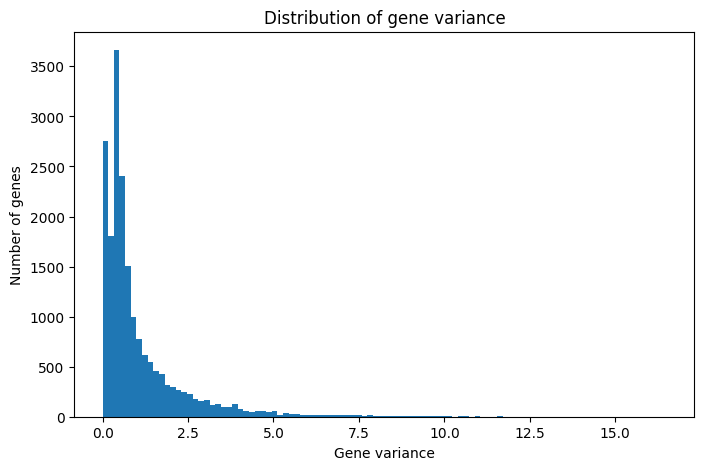

In [13]:
# =============================================================================
# Gene variance distribution
# =============================================================================

plt.figure(figsize=(8, 5))

plt.hist(
    gene_variance,
    bins=100
)

plt.xlabel("Gene variance")
plt.ylabel("Number of genes")
plt.title("Distribution of gene variance")

plt.show()

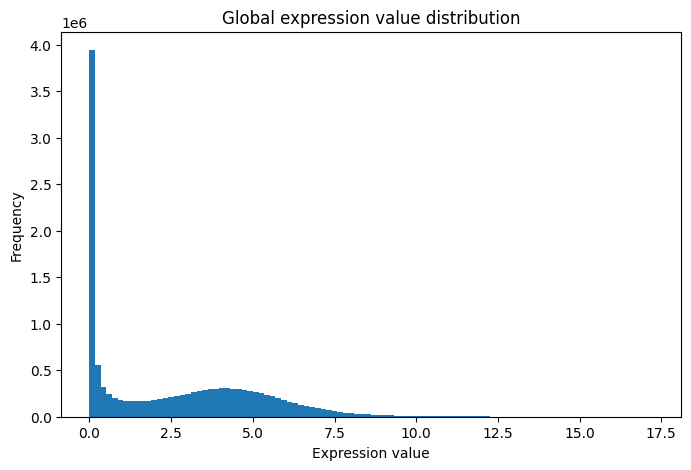

In [14]:
# =============================================================================
# Global expression distribution
# =============================================================================

expression_values = expression_only.to_numpy().ravel()

plt.figure(figsize=(8, 5))

plt.hist(
    expression_values,
    bins=100
)

plt.xlabel("Expression value")
plt.ylabel("Frequency")
plt.title("Global expression value distribution")

plt.show()

## Quality Assessment Results

The harmonized expression matrix contains 713 cell lines and 19,193 protein-coding genes, yielding a complete transcriptomic representation of the integrated modeling cohort.

A structural audit identified a single identifier column (`ModelID`) and 19,193 numeric gene-expression features stored as `float64` values. No missing values were detected across the matrix, indicating complete transcriptomic coverage for all retained models and genes.

Variance analysis revealed only 10 zero-variance genes across the entire cohort. These genes exhibit constant expression values in all 713 cell lines and therefore do not contribute discriminatory information for downstream analyses.

The distribution of gene variances is strongly right-skewed, with most genes displaying low-to-moderate variability and a smaller subset exhibiting high variability across cell lines. This pattern is consistent with large-scale transcriptomic datasets and suggests the presence of biologically informative variation within the cohort.

Similarly, the global expression-value distribution exhibits the expected shape for log-transformed TPM measurements, characterized by a large proportion of lowly expressed genes and a broader distribution of moderately to highly expressed transcripts.

Overall, no major structural issues were identified. The expression matrix appears suitable for downstream transcriptomic analyses.

In [15]:
# =============================================================================
# Expression integration summary
# =============================================================================

summary = pd.DataFrame({
    "metric": [
        "models",
        "genes",
        "missing_values",
        "columns_with_missing_values",
        "zero_variance_genes"
    ],
    "value": [
        n_models,
        n_genes,
        total_missing,
        (missing_per_column > 0).sum(),
        len(zero_variance_genes)
    ]
})

display(summary)

,metric,value
0,models,713
1,genes,19193
2,missing_values,0
3,columns_with_missing_values,0
4,zero_variance_genes,10


In [16]:
# =============================================================================
# Duplicate ModelID audit
# =============================================================================

duplicated_models = expression_harmonized["ModelID"].duplicated().sum()

print(f"Duplicated ModelIDs: {duplicated_models}")

Duplicated ModelIDs: 0


In [17]:
# =============================================================================
# Data type optimization
# =============================================================================

gene_columns = expression_harmonized.columns.drop("ModelID")

expression_harmonized[gene_columns] = expression_harmonized[gene_columns].astype(
    "float32"
)

display(expression_harmonized.dtypes.value_counts())

float32    19193
object         1
Name: count, dtype: int64

### Data Type Optimization

Before persistence, transcriptomic features were converted from `float64` to `float32`.

The expression matrix contains log-transformed TPM values and does not require double-precision numerical representation. Using `float32` reduces memory usage and storage requirements while preserving sufficient precision for downstream transcriptomic analyses, dimensionality reduction, and machine-learning workflows.

In [18]:
# =============================================================================
# Save harmonized expression matrix
# =============================================================================

expression_harmonized.to_parquet(
    INTERIM_DIR / "23_expression_harmonized.parquet",
    index=False
)